# Import Libraries

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import (f1_score, cohen_kappa_score,
                             confusion_matrix, classification_report)
import seaborn as sns
import gc

mne.set_log_level('WARNING')
torch.manual_seed(42)
np.random.seed(42)

print("PyTorch:", torch.__version__)
print("GPU    :", torch.cuda.is_available())
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
stage_names = ['W', 'N1', 'N2', 'N3', 'REM']
print("Device :", DEVICE)

PyTorch: 2.11.0+cu128
GPU    : True
Device : cuda


# Data Loading

- Load the preprocessed EEG recordings.
- Each file contains sleep epochs that were already segmented and cleaned during preprocessing.

In [ ]:
PROCESSED_DIR = "/content/drive/MyDrive/Queens_notebooks/processed"
CNN_WEIGHTS   = "/content/drive/MyDrive/Queens_notebooks/processed/cnn_final_model.pth"

all_npz  = sorted(glob.glob(os.path.join(PROCESSED_DIR, "*.npz")))
subjects = [{'name': os.path.basename(f).replace('.npz', ''), 'path': f}
            for f in all_npz]

print(f"Total subjects: {len(subjects)}")

# Same 80/20 split as the CNN+BiLSTM notebook
n_test         = int(len(subjects) * 0.2)
test_subjects  = subjects[:n_test]
train_subjects = subjects[n_test:]

print(f"Train: {len(train_subjects)} subjects")
print(f"Test : {len(test_subjects)}  subjects")

Total subjects: 153
Train: 123 subjects
Test : 30  subjects


- The dataset consists of EEG recordings from multiple subjects. Each subject is stored as a separate `.npz` file. An **80/20** subject-level split is used to ensure that unseen subjects are evaluated during testing, providing a realistic estimate of generalization performance.

# ConvBlock and TwoStreamCNN

**CNN Feature Extractor**

- The feature extraction backbone follows the dual-stream design from DeepSleepNet. The intuition behind two parallel streams comes directly from signal processing: high-frequency events like sleep spindles (~12–15 Hz) and
K-complexes are best captured with short filters, while slow-wave delta activity (<2 Hz) requires long filters to span enough time. Rather than choosing one or the
other, both streams run in parallel and their outputs are concatenated, giving the
network access to both temporal scales simultaneously.

- Each stream consists of three ConvBlocks.        
     - Every block applies a 1D convolution.
     - Batch normalisation to stabilise training
     - ReLU activation
     - max-pooling to reduce the temporal dimension
     - Dropout at 50% to prevent overfitting.

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, pool_size):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size,
                      stride=stride, padding=kernel_size // 2),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.MaxPool1d(pool_size),
            nn.Dropout(0.5)
        )

    def forward(self, x):
        return self.block(x)

class TwoStreamCNN(nn.Module):
    def __init__(self, n_classes=5, Fs=100):
        super().__init__()
        self.cnn_small = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs // 2,  stride=Fs // 16, pool_size=8),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=4),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)
        )
        self.cnn_large = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs * 4, stride=Fs // 2, pool_size=4),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        small    = self.cnn_small(x)
        large    = self.cnn_large(x)
        combined = torch.cat([small, large], dim=1)
        return self.classifier(combined)

# CNN + Transformer model

This model replaces the BiLSTM from DeepSleepNet with a Transformer encoder,
following the sequence-level design.

The motivation is that the Transformer's self-attention mechanism can model dependencies between any two epochs in the sequence
directly. regardless of how far apart they are. whereas a BiLSTM must
propagate information step by step, making very long-range dependencies harder
to learn.

The architecture has three stages:

1. **CNN feature extraction** — the same dual-stream CNN as above processes
   each of the 25 epochs in the sequence independently, producing a 256-dimensional
   feature vector per epoch.

2. **Positional encoding** — unlike an LSTM, a Transformer sees all 25 epochs
   simultaneously and has no built-in sense of order. Sinusoidal positional
   encodings (Vaswani et al., 2017) are added to each feature vector to inject
   position information before passing to the Transformer.

3. **Transformer encoder** — 4 layers, 8 attention heads, feedforward dimension
   1024. Each layer applies multi-head self-attention (every epoch attends to
   every other epoch), followed by a position-wise feedforward network and
   layer normalisation. The output at each position is then passed to a linear
   classifier to produce one prediction per epoch in the sequence.

The CNN weights are initialised from the pretrained CNN-only model and kept
nearly frozen during training (lr=1e-6), while the Transformer is trained from
scratch at a higher learning rate (lr=1e-4). This two-rate strategy protects
the useful features already learned by the CNN.

In [ ]:
class CNNTransformer(nn.Module):
    """
    Same two-stream CNN as DeepSleepNet for epoch-level feature extraction.
    Replaces the BiLSTM with a Transformer encoder for sequence-level modelling.

    Based on the sequence-level Transformer idea from:
    Phan et al., SleepTransformer (IEEE TBME 2022)
    """
    def __init__(self, n_classes=5, Fs=100,
                 d_model=256, nhead=8,
                 num_layers=4, dim_feedforward=1024,
                 dropout=0.1):
        super().__init__()

        # Same CNN streams as DeepSleepNet
        self.cnn_small = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs // 2,  stride=Fs // 16, pool_size=8),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=4),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)
        )
        self.cnn_large = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs * 4, stride=Fs // 2, pool_size=4),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)
        )

        # CNN output dim = 128 + 128 = 256 = d_model
        assert d_model == 256, "d_model must match CNN output size (256)"

        # Positional encoding
        # Transformers have no built-in sense of order — positional
        # encoding injects position information into the sequence.
        # We use the standard sinusoidal encoding from Vaswani et al. 2017.
        self.pos_dropout = nn.Dropout(dropout)
        max_len          = 200
        pe               = torch.zeros(max_len, d_model)
        position         = torch.arange(0, max_len).unsqueeze(1).float()
        div_term         = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)                     # (1, max_len, d_model)
        self.register_buffer('pe', pe)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model        = d_model,
            nhead          = nhead,
            dim_feedforward= dim_feedforward,
            dropout        = dropout,
            batch_first    = True              # (batch, seq, features)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer,
                                                  num_layers=num_layers)

        # Classifier
        self.classifier = nn.Linear(d_model, n_classes)
        self.dropout    = nn.Dropout(dropout)

    def extract_cnn_features(self, x):
        """x: (batch, 1, 3000) → (batch, 256)"""
        small    = self.cnn_small(x).squeeze(-1)
        large    = self.cnn_large(x).squeeze(-1)
        return torch.cat([small, large], dim=1)

    def forward(self, x):
        """
        x: (batch, seq_len, 3000)
        Returns: (batch, seq_len, n_classes)
        """
        batch, seq_len, _ = x.shape

        # Extract CNN features for every epoch in the sequence
        cnn_out = torch.stack(
            [self.extract_cnn_features(x[:, t, :].unsqueeze(1))
             for t in range(seq_len)],
            dim=1
        )                                        # (batch, seq_len, 256)

        # Add positional encoding
        cnn_out = cnn_out + self.pe[:, :seq_len, :]
        cnn_out = self.pos_dropout(cnn_out)

        # Transformer encoder — full self-attention over all epochs
        out = self.transformer(cnn_out)          # (batch, seq_len, 256)
        out = self.dropout(out)

        # Classify each epoch
        return self.classifier(out)              # (batch, seq_len, 5)


# check
model     = CNNTransformer()
dummy_seq = torch.zeros(4, 25, 3000)
out       = model(dummy_seq)
print("Output shape    :", out.shape)           # should be (4, 25, 5)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Compare with DeepSleepNet parameter count
class DeepSleepNet(nn.Module):
    def __init__(self, n_classes=5, Fs=100):
        super().__init__()
        self.cnn_small = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs//2,  stride=Fs//16, pool_size=8),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=4),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)
        )
        self.cnn_large = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs*4, stride=Fs//2, pool_size=4),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)
        )
        self.bilstm1    = nn.LSTM(256,  512, batch_first=True, bidirectional=True)
        self.bilstm2    = nn.LSTM(1024, 512, batch_first=True, bidirectional=True)
        self.dropout    = nn.Dropout(0.5)
        self.shortcut   = nn.Linear(256, 1024)
        self.classifier = nn.Linear(1024, n_classes)

    def extract_cnn_features(self, x):
        small = self.cnn_small(x).squeeze(-1)
        large = self.cnn_large(x).squeeze(-1)
        return torch.cat([small, large], dim=1)

    def forward(self, x):
        batch, seq_len, _ = x.shape
        cnn_out = torch.stack(
            [self.extract_cnn_features(x[:, t, :].unsqueeze(1)) for t in range(seq_len)],
            dim=1
        )
        out, _  = self.bilstm1(cnn_out)
        out      = self.dropout(out)
        out, _  = self.bilstm2(out)
        out      = self.dropout(out)
        out      = out + self.shortcut(cnn_out)
        return self.classifier(out)

dsn = DeepSleepNet()
print(f"DeepSleepNet params: {sum(p.numel() for p in dsn.parameters()):,}")
print(f"CNNTransformer params: {sum(p.numel() for p in model.parameters()):,}")

Output shape    : torch.Size([4, 25, 5])
Total parameters: 3,678,981
DeepSleepNet params: 10,240,517
CNNTransformer params: 3,678,981


# Load CNN pretrained weights

## Transfer Learning from Pretrained CNN

- Rather than training the full model from random initialisation, we load the CNN
weights from the best-performing fold of the CNN-only training run.

- This is a **form of transfer learning**: the CNN has already learned to distinguish sleep-relevant frequency patterns (delta waves, sleep spindles, alpha activity) from individual
epochs, so we do not need to re-learn those features from scratch.

Only the `cnn_small` and `cnn_large` stream weights are transferred. The
Transformer encoder and classifier are initialised randomly, as they represent
new components that have no counterpart in the pretrained model.

In [ ]:
# Load CNN weights from the best fold of the CNN-only training
pretrained      = torch.load(CNN_WEIGHTS, map_location=DEVICE, weights_only=True)
cnn_weights     = {k: v for k, v in pretrained.items()
                   if k.startswith('cnn_small') or k.startswith('cnn_large')}

print(f"CNN weight tensors to load: {len(cnn_weights)}")
print("Keys:", list(cnn_weights.keys())[:4], "...")

CNN weight tensors to load: 42
Keys: ['cnn_small.0.block.0.weight', 'cnn_small.0.block.0.bias', 'cnn_small.0.block.1.weight', 'cnn_small.0.block.1.bias'] ...


# Dataset and sequence builder

**Sequential Data Preparation**

- Sleep staging is inherently sequential. The correct label for a given epoch often depends on what came before and after it.

- **For example,** distinguishing N1 from REM requires knowing whether chin EMG tone is present in neighbouring
epochs. To capture this context, we slice each subject's recording intonon-overlapping windows of 25 consecutive epochs so the model sees a 12.5-minute window of sleep at each step.

- Each epoch is also normalised to zero mean and unit variance before being
passed to the model. This simple step removes inter-subject amplitude differences
that are irrelevant to stage classification and stabilises gradient flow through
the convolutional layers, following the preprocessing used in SleepEEGNet.

In [ ]:
class SeqSleepDataset(Dataset):
    """Dataset for sequences of epochs."""
    def __init__(self, X_seq, y_seq):
        self.X = X_seq.astype(np.float32)
        self.y = y_seq.astype(np.int64)
        # Normalize each epoch to zero mean and unit variance
        mean = self.X.mean(axis=-1, keepdims=True)
        std  = self.X.std(axis=-1,  keepdims=True) + 1e-8
        self.X = (self.X - mean) / std

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.FloatTensor(self.X[idx]), torch.LongTensor(self.y[idx])


SEQ_LEN = 25

def make_sequences(epochs, labels, seq_len=25):
    """Slice a subject's recording into non-overlapping windows."""
    X_seqs, y_seqs = [], []
    n = len(labels)
    for start in range(0, n - seq_len + 1, seq_len):
        X_seqs.append(epochs[start : start + seq_len])
        y_seqs.append(labels[start : start + seq_len])
    return np.array(X_seqs), np.array(y_seqs)


# Trial: use 40 training subjects to avoid crash
# Change to train_subjects for the final run
TRIAL_SUBJECTS = train_subjects[:40]

# Build training sequences
X_seq_list, y_seq_list = [], []
for s in TRIAL_SUBJECTS:
    d = np.load(s['path'])
    Xs, ys = make_sequences(d['epochs'], d['labels'], SEQ_LEN)
    X_seq_list.append(Xs)
    y_seq_list.append(ys)
    d.close()

X_train_seq = np.concatenate(X_seq_list)
y_train_seq = np.concatenate(y_seq_list)

# Build test sequences
X_test_list, y_test_list = [], []
for s in test_subjects:
    d = np.load(s['path'])
    Xs, ys = make_sequences(d['epochs'], d['labels'], SEQ_LEN)
    X_test_list.append(Xs)
    y_test_list.append(ys)
    d.close()

X_test_seq = np.concatenate(X_test_list)
y_test_seq = np.concatenate(y_test_list)

print(f"Train sequences: {X_train_seq.shape}")
print(f"Test  sequences: {X_test_seq.shape}")

Train sequences: (1966, 25, 3000)
Test  sequences: (1228, 25, 3000)


#  K-Fold CV

- Five-fold cross-validation is used to evaluate the robustness of the model. In each fold, a different validation subset was used while the remaining data are used for training. This reduces the likelihood that the reported performance is biased by a particular train-validation split.


Fold 1/5 | 1572 train seqs | 394 val seqs
  Epoch 10/30 | Train Loss: 0.5015  Acc: 80.6% | Val Loss: 0.5946  Acc: 78.4%
  Epoch 20/30 | Train Loss: 0.4574  Acc: 82.3% | Val Loss: 0.5156  Acc: 81.3%
  Epoch 30/30 | Train Loss: 0.4272  Acc: 83.2% | Val Loss: 0.5294  Acc: 81.7%

FOLD 1 — Validation Metrics  (CNN + Transformer)
  Accuracy  : 81.75%
  Macro F1  : 74.34%
  Cohen's κ : 0.7414

              precision    recall  f1-score   support

           W       0.95      0.86      0.90      2783
          N1       0.41      0.38      0.39       830
          N2       0.80      0.92      0.85      3960
          N3       0.85      0.68      0.76       675
         REM       0.86      0.76      0.81      1602

    accuracy                           0.82      9850
   macro avg       0.77      0.72      0.74      9850
weighted avg       0.82      0.82      0.82      9850



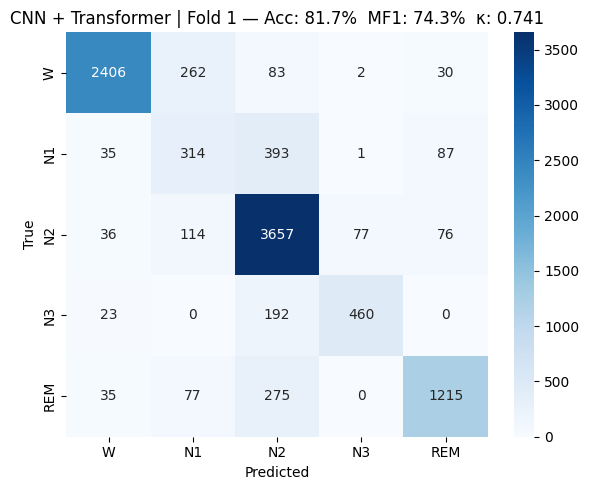

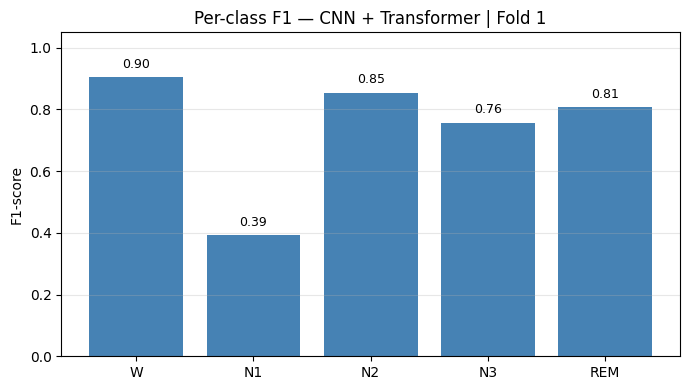


Fold 2/5 | 1573 train seqs | 393 val seqs
  Epoch 10/30 | Train Loss: 0.4872  Acc: 81.4% | Val Loss: 0.5301  Acc: 79.7%
  Epoch 20/30 | Train Loss: 0.4478  Acc: 82.8% | Val Loss: 0.5465  Acc: 78.9%
  Epoch 30/30 | Train Loss: 0.4228  Acc: 83.8% | Val Loss: 0.6748  Acc: 75.6%

FOLD 2 — Validation Metrics  (CNN + Transformer)
  Accuracy  : 75.61%
  Macro F1  : 67.20%
  Cohen's κ : 0.6558

              precision    recall  f1-score   support

           W       0.73      0.92      0.82      2732
          N1       0.52      0.30      0.38      1005
          N2       0.81      0.85      0.83      3960
          N3       0.68      0.75      0.72       756
         REM       0.82      0.50      0.62      1372

    accuracy                           0.76      9825
   macro avg       0.71      0.66      0.67      9825
weighted avg       0.75      0.76      0.74      9825



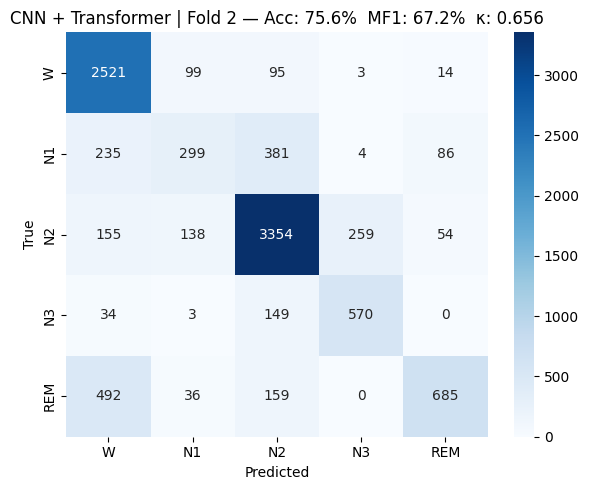

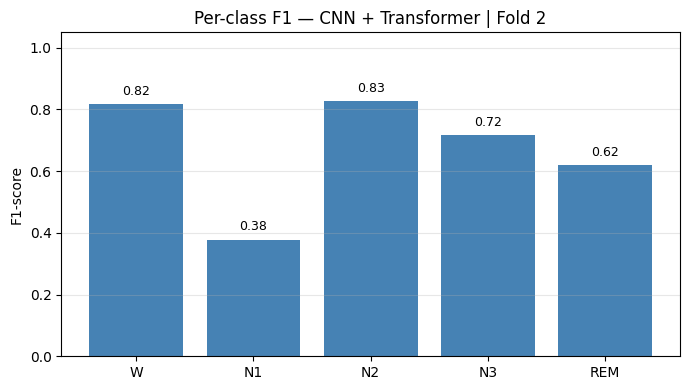


Fold 3/5 | 1573 train seqs | 393 val seqs
  Epoch 10/30 | Train Loss: 0.5058  Acc: 80.3% | Val Loss: 0.4034  Acc: 84.1%
  Epoch 20/30 | Train Loss: 0.4793  Acc: 81.4% | Val Loss: 0.4673  Acc: 80.5%
  Epoch 30/30 | Train Loss: 0.4457  Acc: 82.6% | Val Loss: 0.4441  Acc: 83.5%

FOLD 3 — Validation Metrics  (CNN + Transformer)
  Accuracy  : 83.49%
  Macro F1  : 73.00%
  Cohen's κ : 0.7666

              precision    recall  f1-score   support

           W       0.90      0.96      0.93      3267
          N1       0.73      0.21      0.32       799
          N2       0.81      0.89      0.85      3597
          N3       0.67      0.81      0.74       734
         REM       0.87      0.77      0.82      1428

    accuracy                           0.83      9825
   macro avg       0.80      0.73      0.73      9825
weighted avg       0.83      0.83      0.82      9825



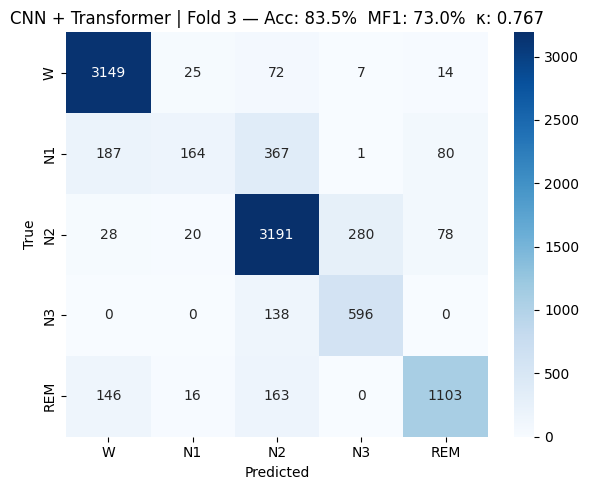

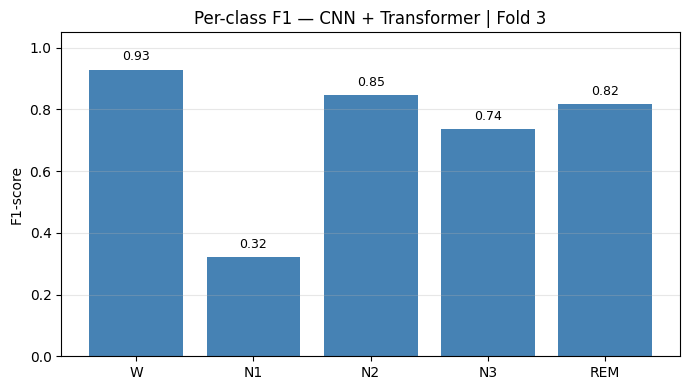


Fold 4/5 | 1573 train seqs | 393 val seqs
  Epoch 10/30 | Train Loss: 0.5072  Acc: 80.4% | Val Loss: 0.5009  Acc: 81.3%
  Epoch 20/30 | Train Loss: 0.4600  Acc: 82.2% | Val Loss: 0.5420  Acc: 80.2%
  Epoch 30/30 | Train Loss: 0.4325  Acc: 83.0% | Val Loss: 0.4909  Acc: 81.9%

FOLD 4 — Validation Metrics  (CNN + Transformer)
  Accuracy  : 81.87%
  Macro F1  : 74.06%
  Cohen's κ : 0.7500

              precision    recall  f1-score   support

           W       0.93      0.91      0.92      2885
          N1       0.61      0.20      0.31      1047
          N2       0.75      0.92      0.83      3488
          N3       0.82      0.78      0.80       828
         REM       0.84      0.85      0.85      1577

    accuracy                           0.82      9825
   macro avg       0.79      0.73      0.74      9825
weighted avg       0.81      0.82      0.80      9825



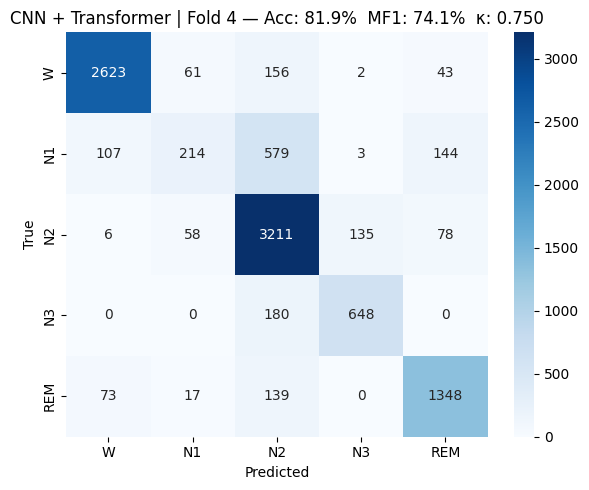

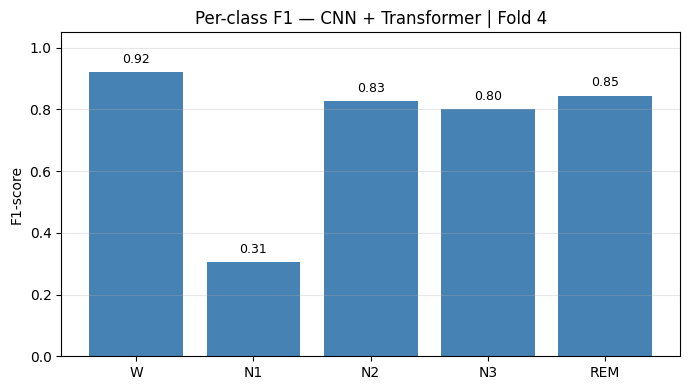


Fold 5/5 | 1573 train seqs | 393 val seqs
  Epoch 10/30 | Train Loss: 0.5230  Acc: 79.9% | Val Loss: 0.6505  Acc: 75.7%
  Epoch 20/30 | Train Loss: 0.4576  Acc: 82.0% | Val Loss: 0.4672  Acc: 83.6%
  Epoch 30/30 | Train Loss: 0.4512  Acc: 82.4% | Val Loss: 0.5354  Acc: 80.2%

FOLD 5 — Validation Metrics  (CNN + Transformer)
  Accuracy  : 80.22%
  Macro F1  : 70.62%
  Cohen's κ : 0.7257

              precision    recall  f1-score   support

           W       0.93      0.95      0.94      3294
          N1       0.56      0.27      0.36       795
          N2       0.80      0.77      0.79      3654
          N3       0.46      0.99      0.62       571
         REM       0.88      0.77      0.82      1511

    accuracy                           0.80      9825
   macro avg       0.72      0.75      0.71      9825
weighted avg       0.82      0.80      0.80      9825



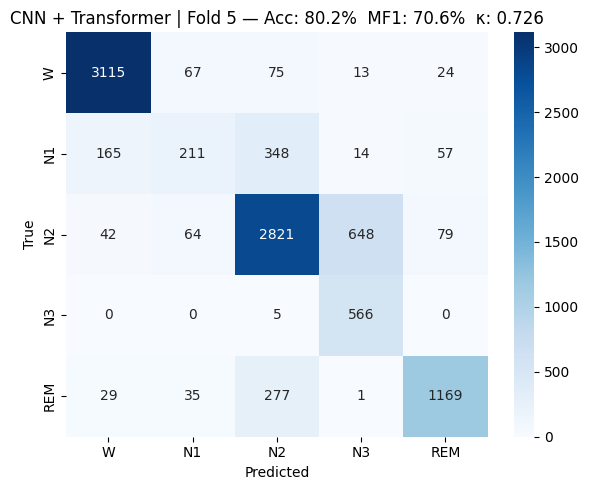

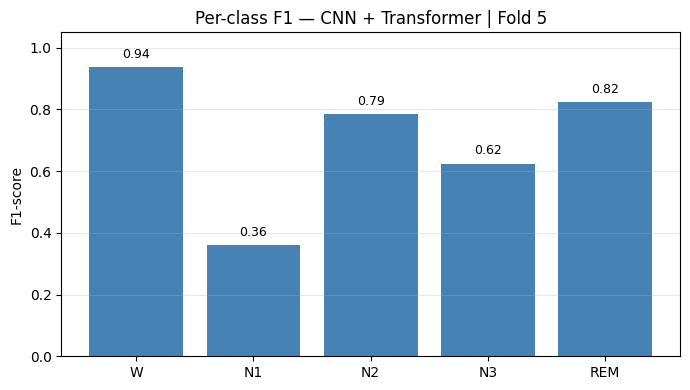

In [ ]:
N_FOLDS  = 5
N_EPOCHS = 30

kf              = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results    = []
fold_histories  = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(range(len(X_train_seq))), 1):

    print(f"\n{'='*55}")
    print(f"Fold {fold}/{N_FOLDS} | {len(tr_idx)} train seqs | {len(val_idx)} val seqs")
    print(f"{'='*55}")

    tr_dataset  = SeqSleepDataset(X_train_seq[tr_idx],  y_train_seq[tr_idx])
    val_dataset = SeqSleepDataset(X_train_seq[val_idx], y_train_seq[val_idx])

    tr_loader  = DataLoader(tr_dataset,  batch_size=16, shuffle=True,  pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True)

    fold_model = CNNTransformer().to(DEVICE)
    model_dict = fold_model.state_dict()
    model_dict.update(cnn_weights)
    fold_model.load_state_dict(model_dict)

    cnn_params   = (list(fold_model.cnn_small.parameters()) +
                    list(fold_model.cnn_large.parameters()))
    trans_params = (list(fold_model.transformer.parameters()) +
                    list(fold_model.classifier.parameters())  +
                    list(fold_model.pos_dropout.parameters()))

    optimizer = torch.optim.Adam([
        {'params': cnn_params,   'lr': 1e-6},
        {'params': trans_params, 'lr': 1e-4},
    ])
    criterion = nn.CrossEntropyLoss()
    history   = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, N_EPOCHS + 1):

        # Train 
        fold_model.train()
        tr_loss, correct, total = 0.0, 0, 0
        for X_b, y_b in tr_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            out      = fold_model(X_b)
            out_flat = out.view(-1, 5)
            y_flat   = y_b.view(-1)
            loss     = criterion(out_flat, y_flat)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(fold_model.parameters(), max_norm=10)
            optimizer.step()
            tr_loss += loss.item()
            correct += (out_flat.argmax(1) == y_flat).sum().item()
            total   += len(y_flat)

        train_loss = tr_loss / len(tr_loader)
        train_acc  = 100 * correct / total

        # Validate 
        fold_model.eval()
        val_loss_total      = 0.0
        all_preds, all_true = [], []
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                out       = fold_model(X_b)
                out_flat  = out.view(-1, 5)
                y_flat    = y_b.view(-1)
                val_loss_total += criterion(out_flat, y_flat).item()
                all_preds.extend(out_flat.argmax(1).cpu().numpy())
                all_true.extend(y_flat.cpu().numpy())

        val_loss = val_loss_total / len(val_loader)
        val_acc  = 100 * np.mean(np.array(all_preds) == np.array(all_true))

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if epoch % 10 == 0:
            print(f"  Epoch {epoch:2d}/{N_EPOCHS} | "
                  f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.1f}% | "
                  f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.1f}%")

    # Fold metrics 
    all_preds    = np.array(all_preds)
    all_true     = np.array(all_true)
    acc          = 100 * (all_preds == all_true).mean()
    mf1          = f1_score(all_true, all_preds, average='macro') * 100
    kappa        = cohen_kappa_score(all_true, all_preds)
    f1_per_class = f1_score(all_true, all_preds, average=None, labels=list(range(5)))
    cm           = confusion_matrix(all_true, all_preds)

    # Print fold metrics 
    print(f"\n{'='*60}")
    print(f"FOLD {fold} — Validation Metrics  (CNN + Transformer)")
    print(f"{'='*60}")
    print(f"  Accuracy  : {acc:.2f}%")
    print(f"  Macro F1  : {mf1:.2f}%")
    print(f"  Cohen's κ : {kappa:.4f}")
    print()
    print(classification_report(all_true, all_preds, target_names=stage_names))

    # Fold confusion matrix 
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=stage_names, yticklabels=stage_names)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"CNN + Transformer | Fold {fold} — "
              f"Acc: {acc:.1f}%  MF1: {mf1:.1f}%  κ: {kappa:.3f}")
    plt.tight_layout()
    plt.show()

    # Fold per-class F1 
    plt.figure(figsize=(7, 4))
    bars = plt.bar(stage_names, f1_per_class, color='steelblue')
    plt.ylabel('F1-score'); plt.ylim(0, 1.05)
    plt.title(f'Per-class F1 — CNN + Transformer | Fold {fold}')
    plt.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, f1_per_class):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

    # Save fold model 
    fold_path = os.path.join(PROCESSED_DIR, f"transformer_fold_{fold}.pth")
    torch.save(fold_model.state_dict(), fold_path)

    fold_results.append({
        'fold'        : fold,
        'acc'         : acc,
        'mf1'         : mf1,
        'kappa'       : kappa,
        'f1_per_class': f1_per_class,
        'cm'          : cm,
        'model_path'  : fold_path,
        'state_dict'  : fold_model.state_dict(),
    })
    fold_histories.append(history)

    del tr_dataset, val_dataset, fold_model, tr_loader, val_loader
    gc.collect()
    torch.cuda.empty_cache()

### CV Summary + Loss Plots

## Training and Validation Loss Curves

- The per-fold loss curves show how training progressed in each individual fold.
The average curve below them aggregates all five folds. The shaded band shows
±1 standard deviation, giving a sense of how consistent training was across
different subject splits. A narrow band indicates the model trains stably
regardless of which subjects end up in training vs validation.


5-Fold CV Summary — CNN + Transformer
Fold          Acc      MF1        κ
--------------------------------------
  1        81.75%   74.34%   0.7414
  2        75.61%   67.20%   0.6558
  3        83.49%   73.00%   0.7666
  4        81.87%   74.06%   0.7500
  5        80.22%   70.62%   0.7257
--------------------------------------
  Mean     80.59%   71.85%   0.7279
  Std       2.69%    2.67%   0.0384

  Representative fold (closest to mean MF1): Fold 3  (MF1: 73.00%  |  Mean: 71.85%)


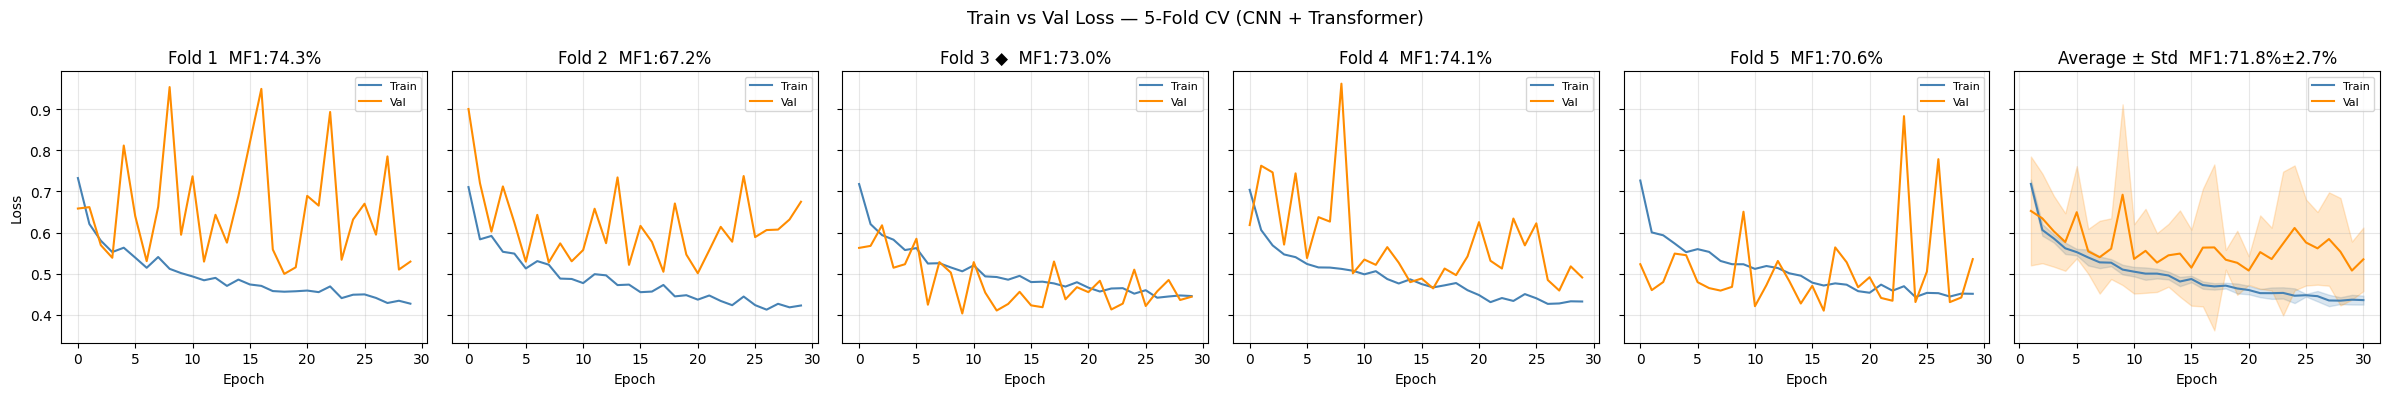

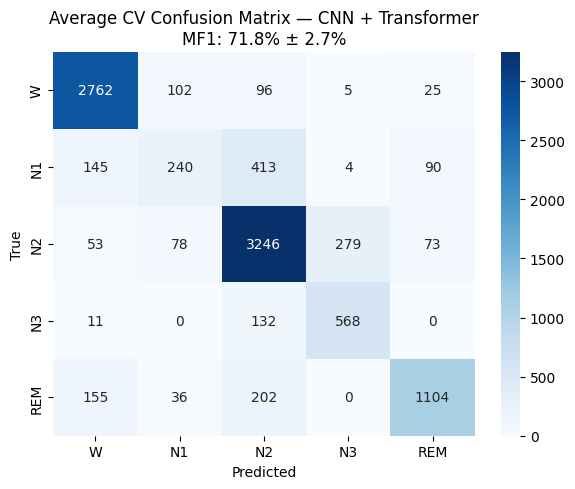

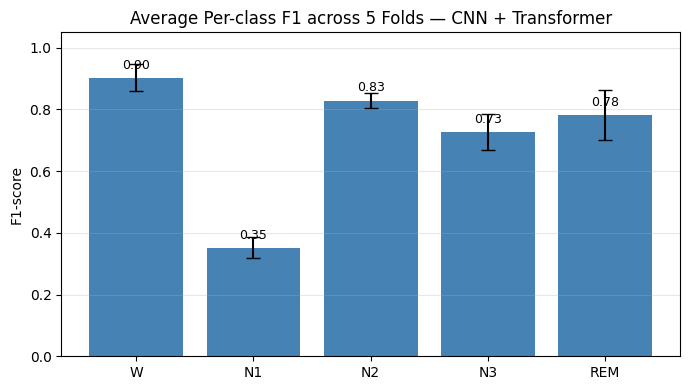

In [ ]:
print(f"\n{'='*50}")
print("5-Fold CV Summary - CNN + Transformer")
print(f"{'='*50}")
print(f"{'Fold':<8} {'Acc':>8} {'MF1':>8} {'κ':>8}")
print("-" * 38)
for r in fold_results:
    print(f"  {r['fold']:<6} {r['acc']:>7.2f}% {r['mf1']:>7.2f}% {r['kappa']:>8.4f}")
print("-" * 38)
accs     = [r['acc']   for r in fold_results]
mf1s     = [r['mf1']   for r in fold_results]
kappas   = [r['kappa'] for r in fold_results]
mean_mf1 = np.mean(mf1s)
print(f"  {'Mean':<6} {np.mean(accs):>7.2f}% {mean_mf1:>7.2f}% {np.mean(kappas):>8.4f}")
print(f"  {'Std':<6} {np.std(accs):>7.2f}% {np.std(mf1s):>7.2f}% {np.std(kappas):>8.4f}")

# Select representative fold (closest to mean MF1) 
avg_fold_idx   = int(np.argmin([abs(m - mean_mf1) for m in mf1s]))
best_trans_fold = fold_results[avg_fold_idx]['fold']
print(f"\n  Representative fold (closest to mean MF1): "
      f"Fold {best_trans_fold}  "
      f"(MF1: {mf1s[avg_fold_idx]:.2f}%  |  Mean: {mean_mf1:.2f}%)")

# Per-fold loss curves + average panel 
n_plots = N_FOLDS + 1
fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), sharey=True)

for i, (ax, h) in enumerate(zip(axes[:N_FOLDS], fold_histories)):
    ax.plot(h['train_loss'], label='Train', color='steelblue')
    ax.plot(h['val_loss'],   label='Val',   color='darkorange')
    marker = ' ◆' if i + 1 == best_trans_fold else ''
    ax.set_title(f'Fold {i+1}{marker}  MF1:{fold_results[i]["mf1"]:.1f}%')
    ax.set_xlabel('Epoch')
    if i == 0:
        ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

ax_avg       = axes[-1]
train_matrix = np.array([h['train_loss'] for h in fold_histories])
val_matrix   = np.array([h['val_loss']   for h in fold_histories])
epochs_range = np.arange(1, N_EPOCHS + 1)

for matrix, color, label in [
    (train_matrix, 'steelblue',  'Train'),
    (val_matrix,   'darkorange', 'Val'),
]:
    mean_ = matrix.mean(axis=0)
    std_  = matrix.std(axis=0)
    ax_avg.plot(epochs_range, mean_, color=color, label=label)
    ax_avg.fill_between(epochs_range, mean_ - std_, mean_ + std_,
                        alpha=0.2, color=color)

ax_avg.set_title(f'Average ± Std  MF1:{mean_mf1:.1f}%±{np.std(mf1s):.1f}%')
ax_avg.set_xlabel('Epoch')
ax_avg.legend(fontsize=8)
ax_avg.grid(alpha=0.3)

fig.suptitle('Train vs Val Loss — 5-Fold CV (CNN + Transformer)', fontsize=13)
plt.tight_layout()
plt.show()

# Average confusion matrix across folds 
avg_cm = np.mean([r['cm'] for r in fold_results], axis=0).astype(int)
plt.figure(figsize=(6, 5))
sns.heatmap(avg_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=stage_names, yticklabels=stage_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"Average CV Confusion Matrix — CNN + Transformer\n"
          f"MF1: {mean_mf1:.1f}% ± {np.std(mf1s):.1f}%")
plt.tight_layout()
plt.show()

# Average per-class F1 with error bars 
avg_f1_pc = np.mean([r['f1_per_class'] for r in fold_results], axis=0)
std_f1_pc = np.std( [r['f1_per_class'] for r in fold_results], axis=0)

plt.figure(figsize=(7, 4))
bars = plt.bar(stage_names, avg_f1_pc, color='steelblue',
               yerr=std_f1_pc, capsize=5)
plt.ylabel('F1-score'); plt.ylim(0, 1.05)
plt.title('Average Per-class F1 across 5 Folds — CNN + Transformer')
plt.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, avg_f1_pc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### Average Weights: Retrain on All Training Data

Averaging weights across all 5 fold models...
Averaged weights loaded ✓

Retraining on full training data (1,966 sequences)...
  Epoch  1/10 | Loss: 0.6746 | Acc: 75.8%
  Epoch  2/10 | Loss: 0.5583 | Acc: 79.2%
  Epoch  3/10 | Loss: 0.5468 | Acc: 79.4%
  Epoch  4/10 | Loss: 0.5105 | Acc: 80.7%
  Epoch  5/10 | Loss: 0.5099 | Acc: 80.4%
  Epoch  6/10 | Loss: 0.4887 | Acc: 81.4%
  Epoch  7/10 | Loss: 0.4877 | Acc: 81.4%
  Epoch  8/10 | Loss: 0.4797 | Acc: 81.7%
  Epoch  9/10 | Loss: 0.4607 | Acc: 82.6%
  Epoch 10/10 | Loss: 0.4593 | Acc: 82.2%

Final model saved → transformer_final_model.pth


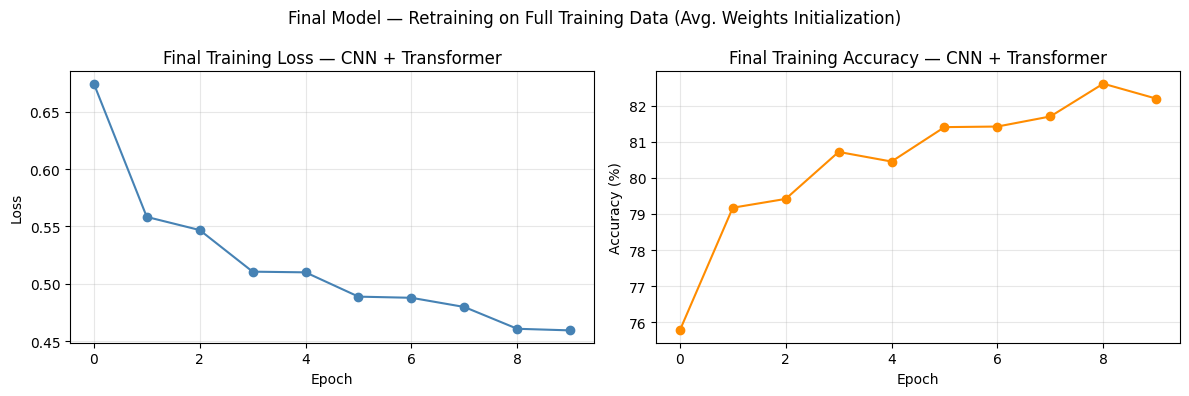


Evaluating on full training data (sanity check)...

Training Set Results — Final CNN + Transformer Model
Accuracy  : 81.09%
Macro F1  : 72.36%
Cohen's κ : 0.7359

              precision    recall  f1-score   support

           W       0.89      0.94      0.91     14961
          N1       0.44      0.53      0.48      4476
          N2       0.82      0.87      0.85     18659
          N3       0.95      0.40      0.57      3564
         REM       0.86      0.76      0.81      7490

    accuracy                           0.81     49150
   macro avg       0.79      0.70      0.72     49150
weighted avg       0.82      0.81      0.81     49150



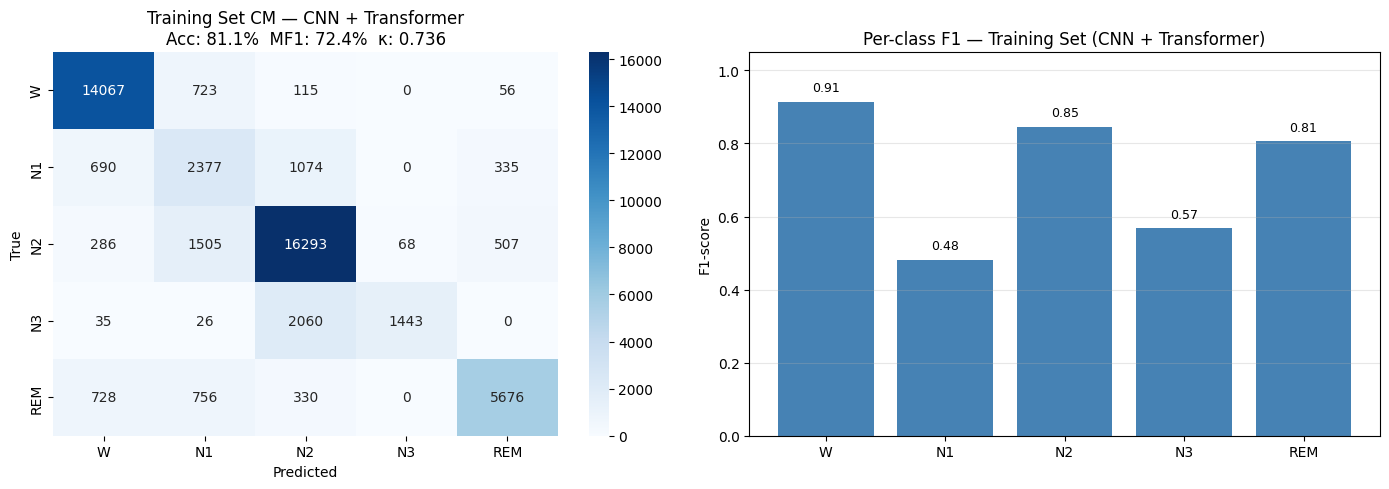

In [ ]:
# Step 1: Average weights across all 5 fold models 
print("Averaging weights across all 5 fold models...")
avg_state = {}
for key in fold_results[0]['state_dict'].keys():
    avg_state[key] = torch.stack(
        [fold_results[i]['state_dict'][key].float() for i in range(N_FOLDS)]
    ).mean(dim=0)

final_trans_model = CNNTransformer().to(DEVICE)
final_trans_model.load_state_dict(avg_state)
print("Averaged weights loaded ✓")

# Step 2: Retrain on ALL training sequences 
print(f"\nRetraining on full training data ({len(X_train_seq):,} sequences)...")

full_seq_dataset = SeqSleepDataset(X_train_seq, y_train_seq)
full_seq_loader  = DataLoader(full_seq_dataset, batch_size=16,
                               shuffle=True, pin_memory=True)

cnn_params_f   = (list(final_trans_model.cnn_small.parameters()) +
                  list(final_trans_model.cnn_large.parameters()))
trans_params_f = (list(final_trans_model.transformer.parameters()) +
                  list(final_trans_model.classifier.parameters())  +
                  list(final_trans_model.pos_dropout.parameters()))

optimizer_final = torch.optim.Adam([
    {'params': cnn_params_f,   'lr': 1e-6},
    {'params': trans_params_f, 'lr': 1e-4},
])
criterion      = nn.CrossEntropyLoss()
N_FINAL_EPOCHS = 10
final_history  = {'train_loss': [], 'train_acc': []}

for epoch in range(1, N_FINAL_EPOCHS + 1):
    final_trans_model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X_b, y_b in full_seq_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer_final.zero_grad()
        out      = final_trans_model(X_b)
        out_flat = out.view(-1, 5)
        y_flat   = y_b.view(-1)
        loss     = criterion(out_flat, y_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_trans_model.parameters(), max_norm=10)
        optimizer_final.step()
        total_loss += loss.item()
        correct    += (out_flat.argmax(1) == y_flat).sum().item()
        total      += len(y_flat)

    train_loss = total_loss / len(full_seq_loader)
    train_acc  = 100 * correct / total
    final_history['train_loss'].append(train_loss)
    final_history['train_acc'].append(train_acc)
    print(f"  Epoch {epoch:2d}/{N_FINAL_EPOCHS} | "
          f"Loss: {train_loss:.4f} | Acc: {train_acc:.1f}%")

final_trans_model_path = os.path.join(PROCESSED_DIR, "transformer_final_model.pth")
torch.save(final_trans_model.state_dict(), final_trans_model_path)
print(f"\nFinal model saved → transformer_final_model.pth")

# Step 3: Final training curve 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(final_history['train_loss'], color='steelblue', marker='o')
ax1.set_title('Final Training Loss - CNN + Transformer')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

ax2.plot(final_history['train_acc'], color='darkorange', marker='o')
ax2.set_title('Final Training Accuracy - CNN + Transformer')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.grid(alpha=0.3)

fig.suptitle('Final Model - Retraining on Full Training Data '
             '(Avg. Weights Initialization)', fontsize=12)
plt.tight_layout()
plt.show()

# Step 4: Training set evaluation 
print("\nEvaluating on full training data (sanity check)...")
final_trans_model.eval()
tr_preds, tr_true = [], []
with torch.no_grad():
    for X_b, y_b in full_seq_loader:
        out      = final_trans_model(X_b.to(DEVICE))
        out_flat = out.view(-1, 5)
        y_flat   = y_b.view(-1)
        tr_preds.extend(out_flat.argmax(1).cpu().numpy())
        tr_true.extend(y_flat.cpu().numpy())

tr_pred = np.array(tr_preds)
tr_true = np.array(tr_true)

tr_acc   = 100 * (tr_pred == tr_true).mean()
tr_mf1   = f1_score(tr_true, tr_pred, average='macro') * 100
tr_kappa = cohen_kappa_score(tr_true, tr_pred)
tr_f1_pc = f1_score(tr_true, tr_pred, average=None, labels=list(range(5)))
tr_cm    = confusion_matrix(tr_true, tr_pred)

print(f"\nTraining Set Results — Final CNN + Transformer Model")
print(f"{'='*50}")
print(f"Accuracy  : {tr_acc:.2f}%")
print(f"Macro F1  : {tr_mf1:.2f}%")
print(f"Cohen's κ : {tr_kappa:.4f}")
print()
print(classification_report(tr_true, tr_pred, target_names=stage_names))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(tr_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=stage_names, yticklabels=stage_names, ax=ax1)
ax1.set_xlabel("Predicted"); ax1.set_ylabel("True")
ax1.set_title(f"Training Set CM — CNN + Transformer\n"
              f"Acc: {tr_acc:.1f}%  MF1: {tr_mf1:.1f}%  κ: {tr_kappa:.3f}")

bars = ax2.bar(stage_names, tr_f1_pc, color='steelblue')
ax2.set_ylabel('F1-score'); ax2.set_ylim(0, 1.05)
ax2.set_title('Per-class F1 — Training Set (CNN + Transformer)')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, tr_f1_pc):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Final Evaluation on Held-Out Test Subjects

The representative model (fold closest to the mean Macro F1) is now evaluated
on the 30 subjects that were set aside at the very beginning and never seen
during training or cross-validation. This gives an unbiased estimate of how
the model would perform on genuinely new patients.

We report five metrics: overall accuracy, macro F1-score (treats all five stages equally regardless of class frequency), Cohen's κ (agreement above
chance), per-class F1-score (to identify which stages are hardest), and the
full confusion matrix (to see the direction of misclassifications).

Final CNN + Transformer model loaded for test evaluation ✓
Test sequences: 1,228

Test Results — Final CNN + Transformer Model
Accuracy  : 79.14%
Macro F1  : 72.39%
Cohen's κ : 0.7049

              precision    recall  f1-score   support

           W       0.81      0.90      0.85      5138
          N1       0.42      0.47      0.44      2225
          N2       0.80      0.88      0.84     13494
          N3       0.96      0.48      0.64      4152
         REM       0.85      0.83      0.84      5691

    accuracy                           0.79     30700
   macro avg       0.77      0.71      0.72     30700
weighted avg       0.81      0.79      0.79     30700



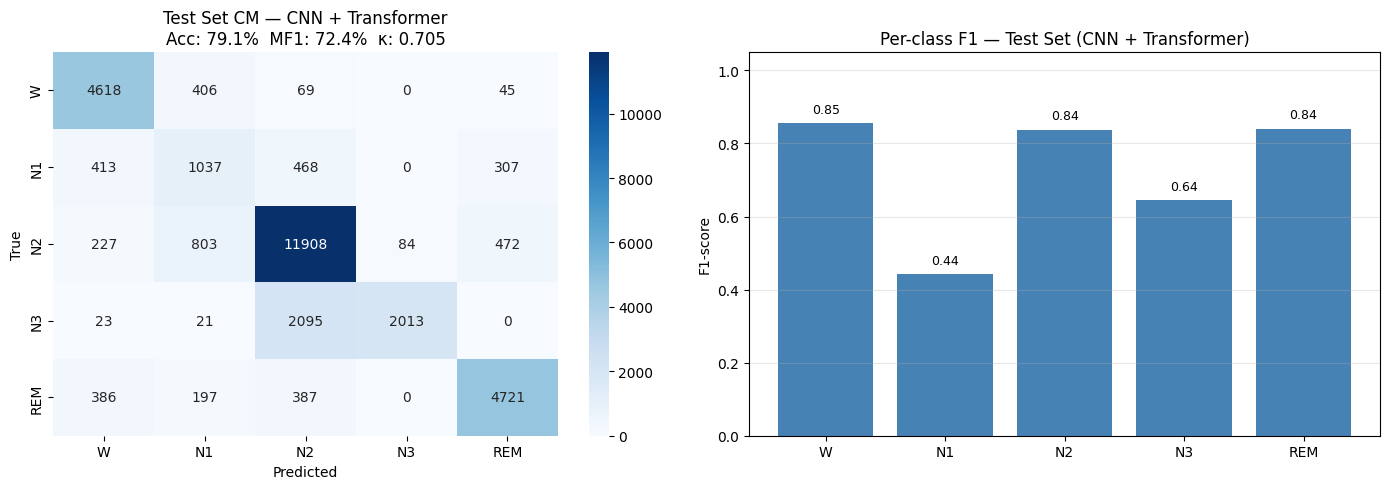

In [ ]:
final_trans_model.load_state_dict(
    torch.load(final_trans_model_path, map_location=DEVICE, weights_only=True)
)
final_trans_model.eval()
print("Final CNN + Transformer model loaded for test evaluation ✓")

test_seq_dataset = SeqSleepDataset(X_test_seq, y_test_seq)
test_seq_loader  = DataLoader(test_seq_dataset, batch_size=32,
                               shuffle=False, pin_memory=True)
print(f"Test sequences: {len(test_seq_dataset):,}")

all_preds, all_true = [], []
with torch.no_grad():
    for X_b, y_b in test_seq_loader:
        out      = final_trans_model(X_b.to(DEVICE))
        out_flat = out.view(-1, 5)
        y_flat   = y_b.view(-1)
        all_preds.extend(out_flat.argmax(1).cpu().numpy())
        all_true.extend(y_flat.cpu().numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_true)

acc          = 100 * (y_pred == y_true).mean()
mf1          = f1_score(y_true, y_pred, average='macro') * 100
kappa        = cohen_kappa_score(y_true, y_pred)
f1_per_class = f1_score(y_true, y_pred, average=None, labels=list(range(5)))
cm           = confusion_matrix(y_true, y_pred)

print(f"\nTest Results — Final CNN + Transformer Model")
print(f"{'='*50}")
print(f"Accuracy  : {acc:.2f}%")
print(f"Macro F1  : {mf1:.2f}%")
print(f"Cohen's κ : {kappa:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=stage_names))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=stage_names, yticklabels=stage_names, ax=ax1)
ax1.set_xlabel("Predicted"); ax1.set_ylabel("True")
ax1.set_title(f"Test Set CM — CNN + Transformer\n"
              f"Acc: {acc:.1f}%  MF1: {mf1:.1f}%  κ: {kappa:.3f}")

bars = ax2.bar(stage_names, f1_per_class, color='steelblue')
ax2.set_ylabel('F1-score'); ax2.set_ylim(0, 1.05)
ax2.set_title('Per-class F1 — Test Set (CNN + Transformer)')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, f1_per_class):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()